# Outputs Analysis

This notebook analyzes benchmark results for `experiment_id = "exp_lattes_001"` under `./outputs` using the current artifact model:

- `runs.jsonl`
- `results.jsonl`
- `evaluation.jsonl`
- `traces/<task>/<run>.json`

It rebuilds a single analysis table by joining run metadata, execution results, evaluation scores, and trace metrics.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 160)
plt.rcParams['figure.figsize'] = (10, 5)

OUTPUTS_ROOT = Path('./outputs')
EXPERIMENT_ID = 'exp_lattes_003'
EXPERIMENT_DIR = OUTPUTS_ROOT / EXPERIMENT_ID
assert EXPERIMENT_DIR.exists(), f'Experiment directory not found: {EXPERIMENT_DIR.resolve()}'


In [2]:
def read_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    rows = []
    with path.open(encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_trace(experiment_dir: Path, trace_ref: str | None) -> dict:
    if not trace_ref:
        return {}
    trace_path = experiment_dir / trace_ref
    if not trace_path.exists():
        return {}
    payload = json.loads(trace_path.read_text(encoding='utf-8'))
    trace = payload.get('trace', {})
    return trace if isinstance(trace, dict) else {}


def flatten_dict(data: dict | None, prefix: str = '') -> dict:
    if not isinstance(data, dict):
        return {}
    flat = {}
    for key, value in data.items():
        column = f'{prefix}{key}'
        if isinstance(value, dict):
            flat.update(flatten_dict(value, prefix=f'{column}_'))
        elif isinstance(value, list):
            flat[column] = json.dumps(value, ensure_ascii=False)
        else:
            flat[column] = value
    return flat


def parse_question_family(question_id: str) -> str:
    if not isinstance(question_id, str):
        return 'unknown'
    parts = question_id.split('_')
    if len(parts) >= 3:
        return parts[1]
    return question_id


experiment = {
    'experiment_dir': EXPERIMENT_DIR,
    'experiment_id': EXPERIMENT_ID,
    'runs': read_jsonl(EXPERIMENT_DIR / 'runs.jsonl'),
    'results': read_jsonl(EXPERIMENT_DIR / 'results.jsonl'),
    'evaluations': read_jsonl(EXPERIMENT_DIR / 'evaluation.jsonl'),
}

print(EXPERIMENT_ID, len(experiment['runs']), len(experiment['results']), len(experiment['evaluations']))


exp_lattes_003 56 56 53


In [12]:
rows = []

run_by_id = {row.get('runId'): row for row in experiment['runs']}
evaluation_by_run_id = {row.get('runId'): row for row in experiment['evaluations']}

for result in experiment['results']:
    run = run_by_id.get(result.get('runId'), {})
    evaluation = evaluation_by_run_id.get(result.get('runId'), {})
    trace = load_trace(experiment['experiment_dir'], result.get('traceRef'))
    metrics = trace.get('aiTrace', {}).get('metrics', {}) if isinstance(trace, dict) else {}
    tool_calls = trace.get('toolCalls', []) if isinstance(trace, dict) else []

    row = {
        'experiment_id': experiment['experiment_id'],
        'run_id': result.get('runId'),
        'question_id': run.get('questionId'),
        'question_family': parse_question_family(run.get('questionId')),
        'context_id': run.get('contextId'),
        'provider': run.get('provider'),
        'model': run.get('model'),
        'strategy': run.get('strategy'),
        'format': run.get('format'),
        'repeat_index': run.get('repeatIndex'),
        'status': result.get('status'),
        'errorMessage': result.get('errorMessage'),
        'answer': result.get('answer'),
        'duration_ms': (result.get('timing') or {}).get('durationMs'),
        'input_tokens': (result.get('usage') or {}).get('inputTokens'),
        'output_tokens': (result.get('usage') or {}).get('outputTokens'),
        'total_tokens': (result.get('usage') or {}).get('totalTokens'),
        'trace_ref': result.get('traceRef'),
        'score': evaluation.get('score'),
        'label': evaluation.get('label'),
        'model_calls': metrics.get('model_calls'),
        'mcp_tool_calls': metrics.get('mcp_tool_calls'),
        'prompt_size_chars': metrics.get('prompt_size_chars'),
        'context_size_chars': metrics.get('context_size_chars'),
        'strategy_duration_ms': metrics.get('strategy_duration_ms'),
        'total_duration_ms': metrics.get('total_duration_ms'),
        'estimated_input_tokens': metrics.get('estimated_input_tokens'),
        'estimated_output_tokens': metrics.get('estimated_output_tokens'),
        'reserved_tokens': metrics.get('reserved_tokens'),
        'rate_limit_wait_ms': metrics.get('rate_limit_wait_ms'),
        'retry_count': metrics.get('retry_count'),
        'retry_sleep_ms': metrics.get('retry_sleep_ms'),
        'tool_call_count': len(tool_calls),
        'has_trace': bool(result.get('traceRef')),
        'success': result.get('status') == 'success',
    }
    row.update(flatten_dict(evaluation.get('details'), prefix='eval_'))
    rows.append(row)

df = pd.DataFrame(rows)
assert not df.empty, 'No runs found to analyze.'
df['duration_s'] = df['duration_ms'] / 1000.0
df['context_kchars'] = df['context_size_chars'] / 1000.0
df['prompt_kchars'] = df['prompt_size_chars'] / 1000.0
df['has_eval'] = df['score'].notna()

print(f'Analysis rows: {len(df)}')
display(df.head())


Analysis rows: 56


,experiment_id,run_id,question_id,question_family,context_id,provider,model,strategy,format,repeat_index,status,errorMessage,answer,duration_ms,input_tokens,output_tokens,total_tokens,trace_ref,score,label,model_calls,mcp_tool_calls,prompt_size_chars,context_size_chars,strategy_duration_ms,total_duration_ms,estimated_input_tokens,estimated_output_tokens,reserved_tokens,rate_limit_wait_ms,retry_count,retry_sleep_ms,tool_call_count,has_trace,success,eval_acceptedAnswers,eval_answerType,eval_comparator,eval_expected,eval_expectedNormalized,eval_extractedAnswer,eval_justification,eval_matchedCriteria,eval_missingCriteria,eval_rubric,eval_answer,duration_s,context_kchars,prompt_kchars,has_eval
0,exp_lattes_003,a93c6764e2,q_exact_001,exact,5660469902738038,openai,gpt-5.4-nano,inline,json,1,success,NaN,The researcher has **2 publications in 2026** (both listed under “Trabalhos completos publicados em anais de congressos” for 2026).,6000,62855.0,37.0,62892.0,traces/exp_lattes_003/a93c6764e2.json,0.0,incorrect,1,0,229665,229566,5550,5550,57513,1000,58513,NaN,0,NaN,0,True,True,"[""3""]",number,numeric-equality,3,3.0,2.0,NaN,NaN,NaN,NaN,NaN,6.0,229.566,229.665,True
1,exp_lattes_003,05cca7aa64,q_exact_001,exact,5660469902738038,openai,gpt-5.4-nano,mcp,json,1,success,NaN,The researcher has **3 publications** in **2026**.,4000,830.0,44.0,874.0,traces/exp_lattes_003/05cca7aa64.json,1.0,correct,2,1,66,229566,3969,3969,782,1000,1782,NaN,0,NaN,1,True,True,"[""3""]",number,numeric-equality,3,3.0,3.0,NaN,NaN,NaN,NaN,NaN,4.0,229.566,0.066,True
2,exp_lattes_003,d790747782,q_exact_001,exact,7227955029154651,openai,gpt-5.4-nano,inline,json,1,success,NaN,Not enough information.,2000,90524.0,8.0,90532.0,traces/exp_lattes_003/d790747782.json,0.0,incorrect,1,0,281852,281753,2189,2189,70560,1000,71560,NaN,0,NaN,0,True,True,"[""0""]",number,numeric-equality,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,281.753,281.852,True
3,exp_lattes_003,6e9a3e1815,q_exact_001,exact,7227955029154651,openai,gpt-5.4-nano,mcp,json,1,success,NaN,The researcher has **0 publications** in **2026**.,3000,478.0,44.0,522.0,traces/exp_lattes_003/6e9a3e1815.json,1.0,correct,2,1,66,281753,2736,2736,501,1000,1501,NaN,0,NaN,1,True,True,"[""0""]",number,numeric-equality,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,3.0,281.753,0.066,True
4,exp_lattes_003,f784f74799,q_exact_001,exact,5660469902738038,openai,gpt-5.4-nano,inline,html,1,error,Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5.4-nano in organization org-Gq0rXT345yX7EZ6QUjSYZtCQ on tokens per min (TPM): Limit 200...,,29000,NaN,NaN,NaN,traces/exp_lattes_003/f784f74799.json,NaN,NaN,0,0,424062,423963,29212,29212,106113,1000,107113,NaN,4,6278.0,0,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,423.963,424.062,False


## Experiment Summary

In [5]:
summary = pd.DataFrame([{
    'experiment_id': EXPERIMENT_ID,
    'runs': len(df),
    'success_rate_pct': round(df['success'].mean() * 100, 2),
    'mean_score': round(df['score'].dropna().mean(), 4) if df['score'].notna().any() else None,
    'providers': df['provider'].nunique(),
    'models': df['model'].nunique(),
    'strategies': df['strategy'].nunique(),
    'formats': df['format'].nunique(),
    'questions': df['question_id'].nunique(),
    'contexts': df['context_id'].nunique(),
}])
display(summary)


,experiment_id,runs,success_rate_pct,mean_score,providers,models,strategies,formats,questions,contexts
0,exp_lattes_003,56,94.64,0.1887,1,1,2,2,7,2


In [28]:
# df.loc[df['label']=='incorrect', ['run_id', 'question_id', 'status', 'answer', 'label', 'eval_expected', 'eval_extractedAnswer']]
# len(df[df['label']=='incorrect'])
# df.loc[(df['status'] != 'error') & (df['question_family'] == 'exact'), ['label', 'score']]
# df.loc[(df['status'] != 'error') & (df['question_family'] == 'exact'), ['label', 'score']]
df['label'].unique()

<StringArray>
['incorrect', 'correct', nan, 'weak', 'correct-abstention']
Length: 5, dtype: str

## Aggregates

In [7]:
group_cols = ['experiment_id', 'provider', 'model', 'strategy', 'format']
agg = (
    df.groupby(group_cols, dropna=False)
      .agg(
          runs=('run_id', 'count'),
          success_rate=('success', 'mean'),
          mean_score=('score', 'mean'),
          mean_duration_ms=('duration_ms', 'mean'),
          mean_total_tokens=('total_tokens', 'mean'),
          mean_tool_calls=('tool_call_count', 'mean'),
          mean_rate_limit_wait_ms=('rate_limit_wait_ms', 'mean'),
          mean_retry_count=('retry_count', 'mean'),
      )
      .reset_index()
)
agg['success_rate'] = (agg['success_rate'] * 100).round(2)
agg['mean_score'] = agg['mean_score'].round(4)
agg['mean_duration_ms'] = agg['mean_duration_ms'].round(1)
agg['mean_total_tokens'] = agg['mean_total_tokens'].round(1)
agg['mean_tool_calls'] = agg['mean_tool_calls'].round(2)
agg['mean_rate_limit_wait_ms'] = agg['mean_rate_limit_wait_ms'].round(1)
agg['mean_retry_count'] = agg['mean_retry_count'].round(2)
display(agg.sort_values(['experiment_id', 'mean_score', 'success_rate'], ascending=[True, False, False]))

,experiment_id,provider,model,strategy,format,runs,success_rate,mean_score,mean_duration_ms,mean_total_tokens,mean_tool_calls,mean_rate_limit_wait_ms,mean_retry_count
3,exp_lattes_003,openai,gpt-5.4-nano,mcp,json,14,100.00,0.2857,3214.3,5625.9,1.36,NaN,0.07
2,exp_lattes_003,openai,gpt-5.4-nano,mcp,html,14,100.00,0.2143,49571.4,21368.9,1.43,NaN,0.79
1,exp_lattes_003,openai,gpt-5.4-nano,inline,json,14,100.00,0.1429,14928.6,76813.5,0.00,6431.3,1.64
0,exp_lattes_003,openai,gpt-5.4-nano,inline,html,14,78.57,0.0909,26428.6,120041.9,0.00,11585.4,2.43


## Charts

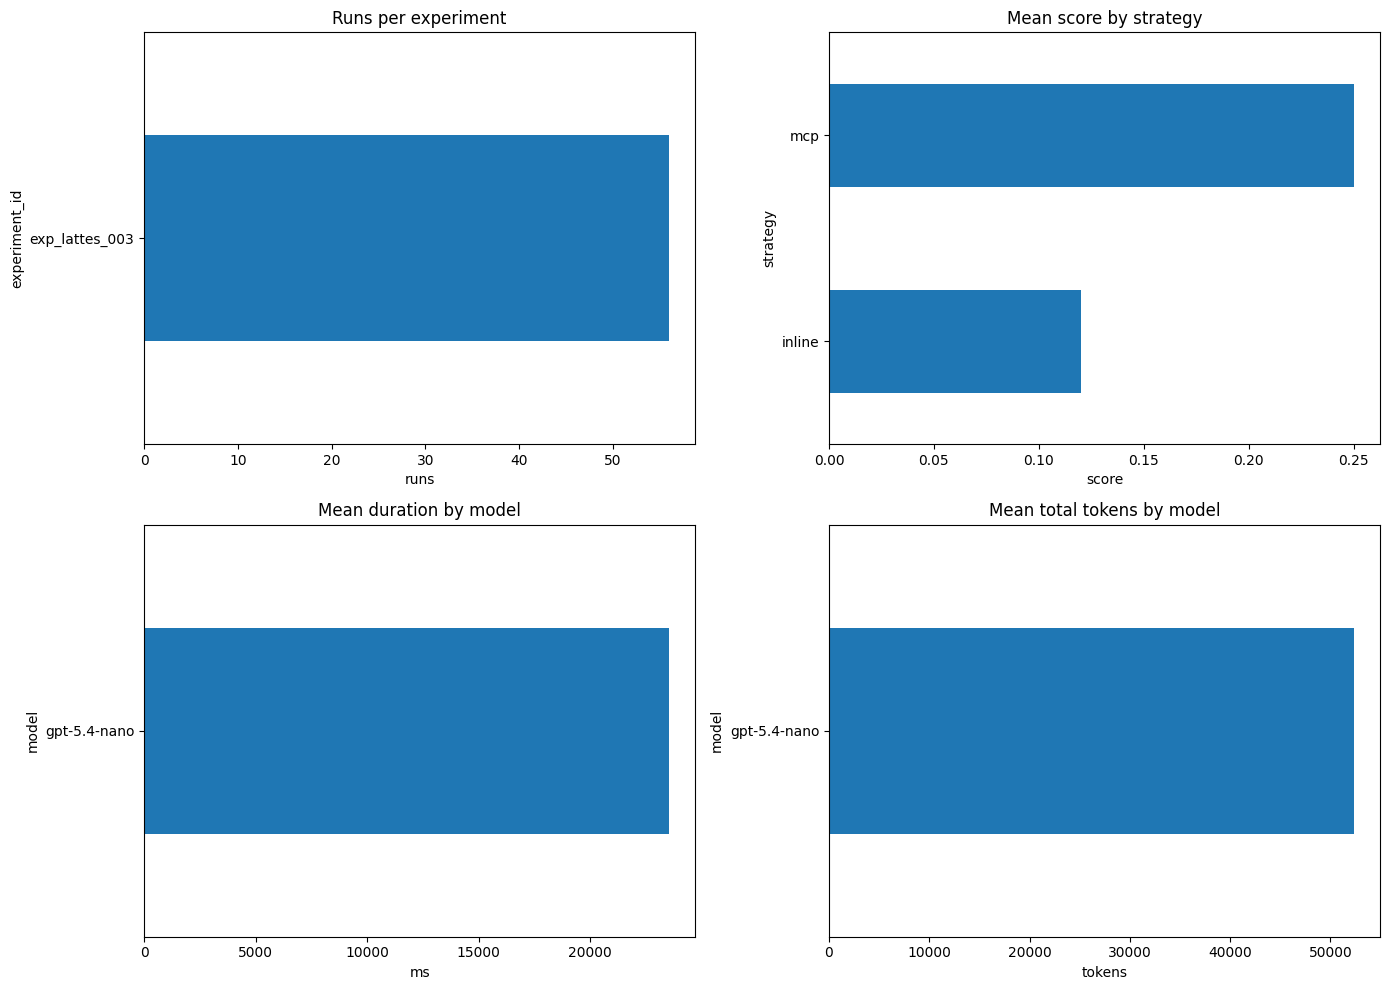

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('experiment_id').size().sort_values().plot(kind='barh', ax=axes[0, 0], title='Runs per experiment')
axes[0, 0].set_xlabel('runs')

(
    df.groupby(['strategy'])['score']
      .mean()
      .sort_values()
      .plot(kind='barh', ax=axes[0, 1], title='Mean score by strategy')
)
axes[0, 1].set_xlabel('score')

(
    df.groupby(['model'])['duration_ms']
      .mean()
      .sort_values()
      .plot(kind='barh', ax=axes[1, 0], title='Mean duration by model')
)
axes[1, 0].set_xlabel('ms')

(
    df.groupby(['model'])['total_tokens']
      .mean()
      .sort_values()
      .plot(kind='barh', ax=axes[1, 1], title='Mean total tokens by model')
)
axes[1, 1].set_xlabel('tokens')

plt.tight_layout()
plt.show()

## Rate Limiting Diagnostics

In [ ]:
rate_diag = (
    df.groupby(['experiment_id', 'provider', 'model'], dropna=False)
      .agg(
          runs=('run_id', 'count'),
          mean_wait_ms=('rate_limit_wait_ms', 'mean'),
          p95_wait_ms=('rate_limit_wait_ms', lambda s: s.dropna().quantile(0.95) if s.notna().any() else None),
          mean_retry_count=('retry_count', 'mean'),
          max_retry_count=('retry_count', 'max'),
          mean_reserved_tokens=('reserved_tokens', 'mean'),
          mean_estimated_output_tokens=('estimated_output_tokens', 'mean'),
      )
      .reset_index()
)
display(rate_diag)

display(Markdown('### Runs with retries or wait time'))
display(
    df.loc[(df['retry_count'].fillna(0) > 0) | (df['rate_limit_wait_ms'].fillna(0) > 0), [
        'experiment_id', 'run_id', 'provider', 'model', 'strategy', 'format', 'question_id',
        'status', 'score', 'duration_ms', 'rate_limit_wait_ms', 'retry_count', 'retry_sleep_ms',
        'reserved_tokens', 'estimated_output_tokens', 'total_tokens'
    ]].sort_values(['rate_limit_wait_ms', 'retry_count'], ascending=[False, False]).head(50)
)

## Failure and Error Inspection

In [ ]:
def load_error_from_trace(experiment_id: str, trace_ref: str | None) -> str | None:
    if not trace_ref:
        return None
    trace = load_trace(OUTPUTS_ROOT / experiment_id, trace_ref)
    error = trace.get('error') if isinstance(trace, dict) else None
    if error:
        return str(error)
    ai_events = ((trace.get('aiTrace') or {}).get('events') or []) if isinstance(trace, dict) else []
    for event in reversed(ai_events):
        metadata = event.get('metadata') or {}
        if metadata.get('error'):
            return str(metadata['error'])
    return None

df['error_message'] = [load_error_from_trace(exp_id, ref) for exp_id, ref in zip(df['experiment_id'], df['trace_ref'])]

display(df.loc[df['status'] != 'success', [
    'experiment_id', 'run_id', 'provider', 'model', 'strategy', 'format', 'question_id',
    'status', 'duration_ms', 'retry_count', 'error_message'
]].sort_values(['experiment_id', 'provider', 'model']))

## Strategy and Format Comparisons

In [ ]:
strategy_format_summary = (
    df.groupby(['experiment_id', 'strategy', 'format'], dropna=False)
      .agg(
          runs=('run_id', 'count'),
          mean_time_ms=('duration_ms', 'mean'),
          error_rate=('success', lambda s: 1 - s.mean()),
          mean_input_tokens=('input_tokens', 'mean'),
          mean_output_tokens=('output_tokens', 'mean'),
          mean_total_tokens=('total_tokens', 'mean'),
          mean_score=('score', 'mean'),
      )
      .reset_index()
)
strategy_format_summary['error_rate_pct'] = (strategy_format_summary['error_rate'] * 100).round(2)
strategy_format_summary['mean_time_ms'] = strategy_format_summary['mean_time_ms'].round(1)
strategy_format_summary['mean_input_tokens'] = strategy_format_summary['mean_input_tokens'].round(1)
strategy_format_summary['mean_output_tokens'] = strategy_format_summary['mean_output_tokens'].round(1)
strategy_format_summary['mean_total_tokens'] = strategy_format_summary['mean_total_tokens'].round(1)
strategy_format_summary['mean_score'] = strategy_format_summary['mean_score'].round(4)
display(strategy_format_summary.sort_values(['experiment_id', 'strategy', 'format']))


### Mean Time Comparison

In [ ]:
mean_time_pivot = strategy_format_summary.pivot_table(
    index=['experiment_id', 'strategy'],
    columns='format',
    values='mean_time_ms'
)
display(mean_time_pivot)

for experiment_id, subset in strategy_format_summary.groupby('experiment_id'):
    chart = subset.pivot(index='strategy', columns='format', values='mean_time_ms').sort_index()
    ax = chart.plot(kind='bar', title=f'Mean time by strategy/format: {experiment_id}')
    ax.set_ylabel('mean time (ms)')
    ax.set_xlabel('strategy')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Error Comparison

In [ ]:
error_rate_pivot = strategy_format_summary.pivot_table(
    index=['experiment_id', 'strategy'],
    columns='format',
    values='error_rate_pct'
)
display(error_rate_pivot)

for experiment_id, subset in strategy_format_summary.groupby('experiment_id'):
    chart = subset.pivot(index='strategy', columns='format', values='error_rate_pct').sort_index()
    ax = chart.plot(kind='bar', title=f'Error rate by strategy/format: {experiment_id}')
    ax.set_ylabel('error rate (%)')
    ax.set_xlabel('strategy')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Token Usage Comparison

In [ ]:
token_usage_pivot = strategy_format_summary.pivot_table(
    index=['experiment_id', 'strategy'],
    columns='format',
    values='mean_total_tokens'
)
display(token_usage_pivot)
display(strategy_format_summary[['experiment_id', 'strategy', 'format', 'mean_input_tokens', 'mean_output_tokens', 'mean_total_tokens']].sort_values(['experiment_id', 'strategy', 'format']))

for experiment_id, subset in strategy_format_summary.groupby('experiment_id'):
    chart = subset.pivot(index='strategy', columns='format', values='mean_total_tokens').sort_index()
    ax = chart.plot(kind='bar', title=f'Mean total tokens by strategy/format: {experiment_id}')
    ax.set_ylabel('mean total tokens')
    ax.set_xlabel('strategy')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
